In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import importlib
import torch
import model.transformer
import model.data as data
import model.constants as constants
import time
import matplotlib.pyplot as plt
from IPython.display import display
importlib.reload(constants)
importlib.reload(model.transformer)
importlib.reload(data)
print("START: ", time.perf_counter())
if constants.DEBUG: print("Start of file", time.perf_counter())
transformer = model.transformer.Transformer()
if constants.DEBUG: print("Transform made", time.perf_counter())
dev_cutoff = int(0.9 * len(data.full_text)) # TODO add test split
train_data = data.full_text[:dev_cutoff]
dev_data = data.full_text[dev_cutoff:]
X_batch, Y_batch = data.GetRandomBatch(train_data)

START:  33763.730884875


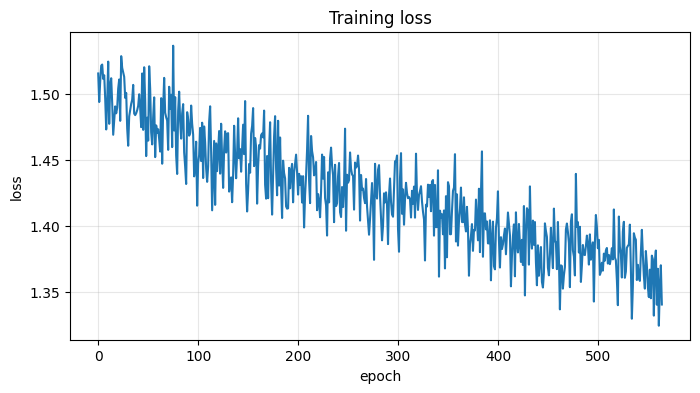

loss: 1.5156846046447754
loss: 1.4940588474273682
loss: 1.5097877979278564
loss: 1.5215914249420166
loss: 1.522435188293457
loss: 1.5115513801574707
loss: 1.5143201351165771
loss: 1.4965765476226807
loss: 1.4733030796051025
loss: 1.4941784143447876
loss: 1.524667739868164
loss: 1.4775573015213013
loss: 1.5070931911468506
loss: 1.5120656490325928
loss: 1.4929325580596924
loss: 1.469283103942871
loss: 1.480212688446045
loss: 1.4907491207122803
loss: 1.4855246543884277
loss: 1.489641785621643
loss: 1.5042153596878052
loss: 1.5111477375030518
loss: 1.479822039604187
loss: 1.5287936925888062
loss: 1.5198683738708496
loss: 1.5165345668792725
loss: 1.5131301879882812
loss: 1.4972114562988281
loss: 1.5009692907333374
loss: 1.4741536378860474
loss: 1.460981845855713
loss: 1.4831531047821045
loss: 1.4876821041107178
loss: 1.4927117824554443
loss: 1.49591064453125
loss: 1.5070350170135498
loss: 1.4853248596191406
loss: 1.4841716289520264
loss: 1.485561728477478
loss: 1.4878945350646973
loss: 1.49

KeyboardInterrupt: 

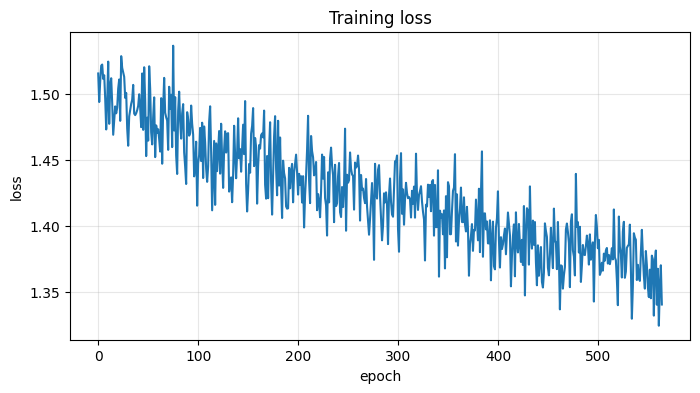

In [14]:

loss_steps = []
loss_history = []
plot_every = 1

fig, ax = plt.subplots(figsize=(8, 4))
(loss_line,) = ax.plot([], [])
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
plot_handle = display(fig, display_id=True)

for i in range(constants.EPOCHS):
    if constants.DEBUG: print("Start", time.perf_counter())
    X_batch, Y_batch = data.GetRandomBatch(train_data);
    if constants.DEBUG: print("Got batches", time.perf_counter())
    out = transformer.forward(X_batch)
    if constants.DEBUG: print("Forwad complete", time.perf_counter(), " dims: ", out.shape)
    loss = transformer.backward(out, Y_batch)
    if constants.DEBUG: print("Backward complete", time.perf_counter())
    if (i % plot_every == 0) or (i == constants.EPOCHS - 1):
        print(f"loss: {loss}")
        loss_steps.append(i)
        loss_history.append(loss)
        loss_line.set_data(loss_steps, loss_history)
        ax.relim()
        ax.autoscale_view()
        if plot_handle is not None:
            plot_handle.update(fig)
        else:
            fig.canvas.draw_idle()
            plt.pause(0.001)

plt.close(fig)

In [18]:
def DecodeTokenList(token_list):
    return data.decode(token_list)


def TestModel(transformer, data_source, n_tokens=10):
    X_test, _ = data.GetRandomBatch(data_source)
    # X_test = X_batch
    context = X_test[0].clone()
    start_context = context.clone()

    print("START:")
    print(DecodeTokenList(context))

    generated_tokens = []

    for i in range(n_tokens):
        # Add fake batch dimension: [T] -> [1, T]
        context_batch = context.view(1, constants.CONTEXT_WINDOW_SIZE)

        # Your transformer currently expects BATCH_SIZE exactly,
        # so repeat the same context BATCH_SIZE times.
        context_batch = context_batch.repeat(constants.BATCH_SIZE, 1)

        # Predict next token from the final position in the first batch row
        with torch.no_grad():
            logits = transformer.forward(context_batch)
        probabilities = torch.softmax(logits, dim=-1)
        pred = torch.multinomial(probabilities[0, -1], num_samples=1)

        generated_tokens.append(pred)

        # Slide context window left and append prediction
        context = torch.cat([context[1:], pred.view(1)], dim=0)
        print(DecodeTokenList(generated_tokens)[-1], end='')

    print("\nGENERATED:")
    print(DecodeTokenList(generated_tokens))

    print("\nFULL:")
    print(DecodeTokenList(start_context) + DecodeTokenList(generated_tokens))

TestModel(transformer, train_data, n_tokens=100)

START:
hou so often hast bestrid,
That horse that I so carefully have dress'd!

KING RICHARD II:
Rode he on Barbary? Tell me, gentle friend,
How went he under him?

Groom:
So proudly as if he disdain'd the ground.

KING RICHARD II:
So proud that Bolingbroke was o
f loyale,
Fore thou thy happiter them too.
O, that's to thee: I live up thy know noble,
I'll brace u
GENERATED:
f loyale,
Fore thou thy happiter them too.
O, that's to thee: I live up thy know noble,
I'll brace u

FULL:
hou so often hast bestrid,
That horse that I so carefully have dress'd!

KING RICHARD II:
Rode he on Barbary? Tell me, gentle friend,
How went he under him?

Groom:
So proudly as if he disdain'd the ground.

KING RICHARD II:
So proud that Bolingbroke was of loyale,
Fore thou thy happiter them too.
O, that's to thee: I live up thy know noble,
I'll brace u


In [ ]:
def ModelContextWindowSize(transformer):
    return transformer.positional_encoding.shape[0]


def EncodeFixedContext(text, context_window_size):
    tokens = data.encode(text)
    if len(tokens) < context_window_size:
        pad_token = data.tokenizer_map[' ']
        tokens = [pad_token] * (context_window_size - len(tokens)) + tokens
    else:
        tokens = tokens[-context_window_size:]
    return torch.tensor(tokens, dtype=torch.int64, device=model.shared.device)


@torch.no_grad()
def ForwardSingleContext(transformer, context_tokens):
    context_window_size = ModelContextWindowSize(transformer)
    context_batch = context_tokens.view(1, context_window_size)
    context_batch = context_batch.repeat(constants.BATCH_SIZE, 1)

    old_context_window_size = constants.CONTEXT_WINDOW_SIZE
    constants.CONTEXT_WINDOW_SIZE = context_window_size
    try:
        logits = transformer.forward(context_batch)
    finally:
        constants.CONTEXT_WINDOW_SIZE = old_context_window_size

    return logits[0, -1, :]


def ShowTopProbs(name, probs, top_k):
    values, indices = probs.topk(top_k)
    print(name)
    for value, index in zip(values, indices):
        ch = data.untokenizer_map[int(index)]
        print(f"  {repr(ch):>6}  {float(value):.4f}")


def CompareContexts(transformer, text1, text2, top_k=10):
    context_window_size = ModelContextWindowSize(transformer)
    ctx1 = EncodeFixedContext(text1, context_window_size)
    ctx2 = EncodeFixedContext(text2, context_window_size)

    logits1 = ForwardSingleContext(transformer, ctx1)
    logits2 = ForwardSingleContext(transformer, ctx2)

    probs1 = torch.softmax(logits1, dim=-1)
    probs2 = torch.softmax(logits2, dim=-1)

    print("CTX 1:", repr(data.decode(ctx1)))
    print("CTX 2:", repr(data.decode(ctx2)))
    print()
    print("max abs logit diff:", (logits1 - logits2).abs().max().item())
    print("mean abs logit diff:", (logits1 - logits2).abs().mean().item())
    print("max abs prob diff:", (probs1 - probs2).abs().max().item())
    print()

    ShowTopProbs("top ctx1:", probs1, top_k)
    print()
    ShowTopProbs("top ctx2:", probs2, top_k)


CompareContexts(
    transformer,
    "To be, or not to be, that is",
    "zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz",
)

CompareContexts(
    transformer,
    "wel in a ten-times-barr'd-up che",
    "xxxxxxxxxxxxxxxxxxxxxxxxxxxxx che",
)

CompareContexts(
    transformer,
    "aaaaaaaaaaaaaaaaaaaaaaaaaaaa the ",
    "bbbbbbbbbbbbbbbbbbbbbbbbbbbb the ",
)


CTX 1: '    To be, or not to be, that is'
CTX 2: 'zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz'

max abs logit diff: 25.632192611694336
mean abs logit diff: 7.0928053855896
max abs prob diff: 0.8826323747634888

top ctx1:
     ' '  0.8898
    '\n'  0.0293
     's'  0.0244
     ','  0.0206
     '.'  0.0076
     ':'  0.0060
     't'  0.0057
     "'"  0.0040
     ';'  0.0023
     '?'  0.0014

top ctx2:
     'e'  0.6839
     'i'  0.1469
     'a'  0.0511
     'o'  0.0327
     'n'  0.0214
     'y'  0.0187
     'u'  0.0174
     ':'  0.0078
     ' '  0.0071
     's'  0.0032
CTX 1: "wel in a ten-times-barr'd-up che"
CTX 2: 'xxxxxxxxxxxxxxxxxxxxxxxxxxxx che'

max abs logit diff: 1.5921783447265625
mean abs logit diff: 0.42408299446105957
max abs prob diff: 0.19279856979846954

top ctx1:
     'a'  0.2849
     'e'  0.2444
     'r'  0.0936
     's'  0.0583
     'm'  0.0526
     'n'  0.0444
     ' '  0.0405
     'i'  0.0343
     'l'  0.0311
     'q'  0.0207

top ctx2:
     'e'  0.4372
     'a'  0.2324
     'r' 